# 09 — Pairwise Manifold Distances

Quantifies how similar encoding manifolds are across datasets (FNN layers, biological Retina/V1, Flyvision, VISp natural movie) using Gromov-Wasserstein (GW) distances and related measures.

## 1. Conceptual Motivation

### Why GW for encoding manifolds (not decoding)?

The **encoding manifold** lives in *neuron space*: each point is a neuron, and pairwise distances capture functional similarity. Comparing encoding manifolds across datasets means comparing two metric-measure spaces where:
- Population sizes differ (N ≈ 340–2000 neurons per dataset)
- No natural neuron-to-neuron correspondence exists across models/species

**Gromov-Wasserstein distance** is ideal here: it finds the optimal isometry-preserving transport between two metric-measure spaces without requiring a correspondence. It asks: *can the intrinsic geometry of one population be mapped onto the other?*

The **decoding manifold** lives in *stimulus space*: each point is one of the 36×8 = 288 stimuli. All datasets see the exact same stimuli, so correspondence is **known**. For decoding manifolds, Procrustes R², RDM correlation, and linear CKA (already in `src/subpop_utils.py`) are more appropriate — exact, cheaper, and interpretable.

### Three distance representations

| Representation | Construction | What it captures |
|---|---|---|
| **Graph metric (SP)** | IAN kernel `wG` → edge distance `-log(w_ij)` → all-pairs shortest-path | Full discrete graph topology |
| **MDS Euclidean** | Recompute diffusion maps + MDS from `wG` → pairwise Euclidean distances | Smooth low-dim manifold geometry |
| **Spectral baseline** | Normalized Laplacian eigenvalue spectra → L2 distance | Cheap sanity check, no GW needed |

### Why entropic GW over exact GW?

For N = 2000 neurons, the exact CG solver takes ~28s per pair × 55 pairs ≈ 26 min. The entropic solver (PPA, ε = 0.01) takes ~0.4s per pair ≈ 22s total. We validate the approximation error on a small pair before committing.

## 2. Imports and Configuration

In [28]:
import sys, os, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.sparse.linalg import eigsh
from scipy.spatial.distance import squareform, pdist
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import MDS as skMDS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ot

from src import (
    normalize_distance_matrix,
    compute_mds_embedding,
    compute_gromov_wasserstein,
    compute_entropic_gw,
    compute_fgw,
)
from ian.embed_utils import diffusionMapSparseK

try:
    from tueplots import bundles
    plt.rcParams.update(bundles.neurips2024())
except ImportError:
    pass
# tueplots enables constrained_layout globally, which conflicts with
# colorbars and seaborn clustermap. Disable it here.
plt.rcParams['figure.constrained_layout.use'] = False

In [29]:
BASEDIR_GRAPHS = '../data/graphs'
BASEDIR_DATA   = '../data/sampled'
BASEDIR_MAT    = '../data/decompositions'

# Dataset registry.  R = CP rank (suffix of graph filename).
# tensor_prefix maps to tensor4d_{tensor_prefix}.npy and neurons_used_{tensor_prefix}.npy
DATASETS = [
    dict(graph='Retina_14.npz',
         tensor_prefix='Retina',                                              R=14,
         label='Bio Retina',   group='biology', nPCs=6),
    dict(graph='V1_17.npz',
         tensor_prefix='V1',                                                  R=17,
         label='Bio V1',       group='biology', nPCs=9),
    dict(graph='flyvis_Retina_i3_n400_model000_6.npz',
         tensor_prefix='flyvis_Retina_i3_n400_model000',                      R=6,
         label='FV Retina',    group='flyvis',  nPCs=None),
    dict(graph='flyvis_Lamina_i3_n350_model000_11.npz',
         tensor_prefix='flyvis_Lamina_i3_n350_model000',                      R=11,
         label='FV Lamina',    group='flyvis',  nPCs=None),
    dict(graph='flyvis_Medulla_i3_n550_model000_11.npz',
         tensor_prefix='flyvis_Medulla_i3_n550_model000',                     R=11,
         label='FV Medulla',   group='flyvis',  nPCs=None),
    dict(graph='flyvis_T_Tm_i3_n1700_model000_11.npz',
         tensor_prefix='flyvis_T_Tm_i3_n1700_model000',                       R=11,
         label='FV T4/Tm',     group='flyvis',  nPCs=None),
    dict(graph='fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1_13.npz',
         tensor_prefix='fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1', R=13,
         label='FNN inputs0',  group='fnn',     nPCs=None),
    dict(graph='fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1_5.npz',
         tensor_prefix='fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1', R=5,
         label='FNN blocks2',  group='fnn',     nPCs=4),
    dict(graph='fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1_10.npz',
         tensor_prefix='fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1',  R=10,
         label='FNN hidden',   group='fnn',     nPCs=None),
    dict(graph='fnn07_seed2_14.npz',
         tensor_prefix='fnn07_seed2',                                         R=14,
         label='FNN readout',  group='fnn',     nPCs=None),
    dict(graph='VISp_natural_movie_one_scenes20_15.npz',
         tensor_prefix='VISp_natural_movie_one_scenes20',                     R=15,
         label='VISp nat.mov', group='biology', nPCs=None),
]

N_DS    = len(DATASETS)
LABELS  = [d['label'] for d in DATASETS]
GROUPS  = [d['group'] for d in DATASETS]
GROUP_COLORS = {'biology': '#2ca02c', 'flyvis': '#ff7f0e', 'fnn': '#1f77b4'}
print(f"{N_DS} datasets: {LABELS}")

11 datasets: ['Bio Retina', 'Bio V1', 'FV Retina', 'FV Lamina', 'FV Medulla', 'FV T4/Tm', 'FNN inputs0', 'FNN blocks2', 'FNN hidden', 'FNN readout', 'VISp nat.mov']


## 3. Load Graphs and Build Distance Representations

In [30]:
def load_graph(graph_fname):
    """Load wG from npz. Returns dense wG array, optScales, disc_pts_indices."""
    d = np.load(os.path.join(BASEDIR_GRAPHS, graph_fname), allow_pickle=True)
    wG = d['wG']
    # wG may be stored as sparse or dense
    if hasattr(wG, 'toarray'):
        wG = wG.toarray()
    elif wG.ndim == 0:  # object array wrapping a sparse matrix
        wG = wG.item().toarray()
    return wG.astype(np.float64), d['optScales'], d['disc_pts_indices']


def wG_to_sp_distance(wG, clip_min=1e-8):
    """IAN kernel matrix → all-pairs shortest-path distance matrix.

    Edge distance = -log(w_ij).  Disconnected pairs (inf) are replaced
    with 2 * max_finite so the matrix stays valid for GW.
    Result is normalized to max=1.
    """
    wG_c = np.where(wG > clip_min, wG, 0.0)
    wG_sp = csr_matrix(wG_c)
    wG_sp.data = -np.log(wG_sp.data)          # kernel weight → distance
    D = shortest_path(wG_sp, directed=False, method='D')
    if not np.all(np.isfinite(D)):
        max_fin = np.nanmax(D[np.isfinite(D)])
        D = np.where(np.isfinite(D), D, 2 * max_fin)
    np.fill_diagonal(D, 0.0)
    return normalize_distance_matrix(D)


def wG_to_mds_distances(wG, nPCs=None, n_diffmap=20, n_mds=10):
    """Recompute diffusion maps + MDS from wG → pairwise Euclidean distances.

    Returns (C_mds, nPCs_used).
    """
    wG_sp = csr_matrix(wG)
    diffmap_y, diffmap_evals = diffusionMapSparseK(wG_sp, n_diffmap, 1, t=1)
    if nPCs is None:
        # Auto-detect: components with eigenvalue > 10% of the second eigenvalue
        threshold = 0.1 * diffmap_evals[1] if len(diffmap_evals) > 1 else 0
        nPCs = max(2, int(np.sum(diffmap_evals[1:] > threshold)))
    emb = compute_mds_embedding(diffmap_y, nPCs, n_components=n_mds)
    C = squareform(pdist(emb, metric='euclidean'))
    return normalize_distance_matrix(C), nPCs


def wG_to_laplacian_spectrum(wG, k=50):
    """Top-k eigenvalues of the normalized graph Laplacian (excluding λ₀=0)."""
    wG_sp = csr_matrix(wG)
    degree = np.array(wG_sp.sum(axis=1)).ravel()
    D_inv_sqrt = sp.diags(1.0 / np.sqrt(degree + 1e-12))
    L = sp.eye(wG_sp.shape[0]) - D_inv_sqrt @ wG_sp @ D_inv_sqrt
    vals, _ = eigsh(L, k=k + 1, which='SM')
    return np.sort(np.real(vals))[1:]  # drop λ₀ ≈ 0

In [31]:
# Load all graphs and build representations
# Total: ~75s on first run (shortest-path dominates); cached runs are instant.
CACHE_GRAPHS = '../data/metrics/_cache_graph_data.npz'
graph_data = {}

if os.path.exists(CACHE_GRAPHS):                                    
    cache = np.load(CACHE_GRAPHS, allow_pickle=True)
    for label in LABELS:
        key = label.replace(' ', '_')
        graph_data[label] = dict(
            wG    = cache[f'{key}_wG'],
            N     = int(cache[f'{key}_N']),
            C_sp  = cache[f'{key}_C_sp'],
            C_mds = cache[f'{key}_C_mds'],
            spectrum = cache[f'{key}_spectrum'],
            nPCs  = int(cache[f'{key}_nPCs']),
        )
    print(f'Loaded graph_data from cache ({CACHE_GRAPHS})')
else:
    for ds in DATASETS:
        label = ds['label']
        t0 = time.time()
        wG, optScales, disc_pts = load_graph(ds['graph'])
        N = wG.shape[0]
        print(f'[{label}] N={N}', end=' | ')

        C_sp = wG_to_sp_distance(wG)
        print('SP', end=' | ')

        C_mds, nPCs_used = wG_to_mds_distances(wG, nPCs=ds['nPCs'])
        print(f'MDS(nPCs={nPCs_used})', end=' | ')

        spectrum = wG_to_laplacian_spectrum(wG, k=50)
        print(f'Spec | {time.time()-t0:.1f}s')

        graph_data[label] = dict(
            wG=wG, N=N, C_sp=C_sp, C_mds=C_mds,
            spectrum=spectrum, nPCs=nPCs_used
        )

    # Save cache
    save_dict = {}
    for label, gd in graph_data.items():
        key = label.replace(' ', '_')
        save_dict[f'{key}_wG']       = gd['wG']
        save_dict[f'{key}_N']        = gd['N']
        save_dict[f'{key}_C_sp']     = gd['C_sp']
        save_dict[f'{key}_C_mds']    = gd['C_mds']
        save_dict[f'{key}_spectrum'] = gd['spectrum']
        save_dict[f'{key}_nPCs']     = gd['nPCs']
    np.savez(CACHE_GRAPHS, **save_dict)
    print(f'\nSaved cache to {CACHE_GRAPHS}')


Loaded graph_data from cache (../data/metrics/_cache_graph_data.npz)


## 4. Sanity Checks

In [32]:
for label, gd in graph_data.items():
    for rep, C in [('C_sp', gd['C_sp']), ('C_mds', gd['C_mds'])]:
        assert np.allclose(C, C.T, atol=1e-8), f"{label} {rep}: not symmetric"
        assert np.allclose(np.diag(C), 0, atol=1e-8), f"{label} {rep}: diagonal not zero"
        assert C.max() <= 1.0 + 1e-8, f"{label} {rep}: max > 1"
print("All distance matrices pass symmetry, zero-diagonal, and max=1 checks.")

All distance matrices pass symmetry, zero-diagonal, and max=1 checks.


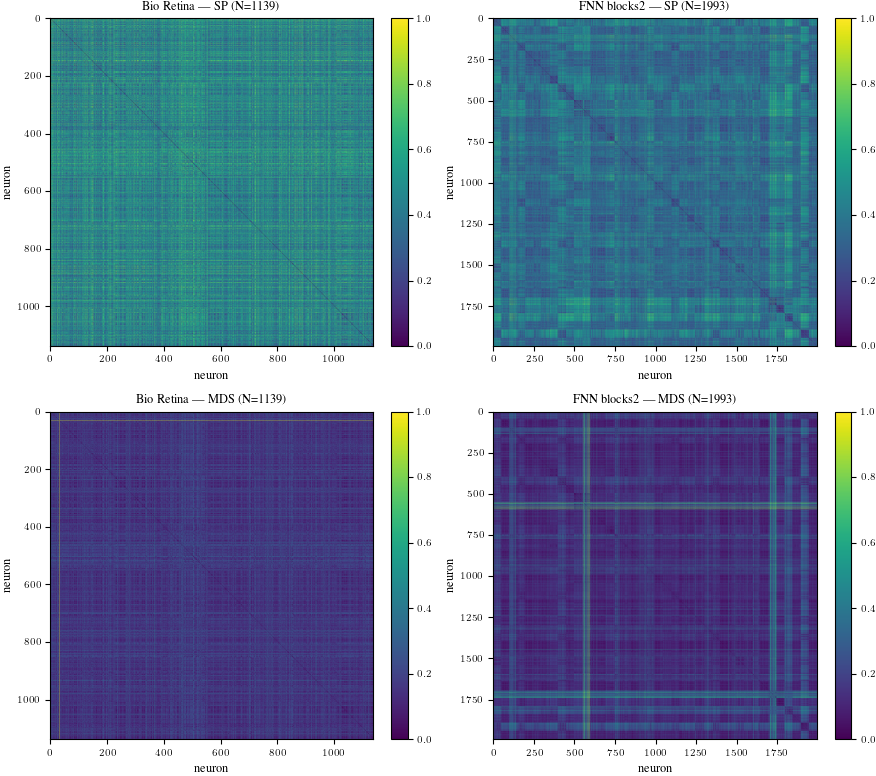

In [33]:
plt.close('all')
# Visual check: heatmaps for Bio Retina and FNN blocks2
check_labels = ['Bio Retina', 'FNN blocks2']
fig, axes = plt.subplots(2, 2, figsize=(9, 8), layout='tight')

for col, label in enumerate(check_labels):
    for row, (rep, key) in enumerate([('SP', 'C_sp'), ('MDS', 'C_mds')]):
        C = graph_data[label][key]
        ax = axes[row, col]
        im = ax.imshow(C, aspect='auto', cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"{label} — {rep} (N={graph_data[label]['N']})")
        ax.set_xlabel('neuron'); ax.set_ylabel('neuron')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.show()


**What this shows:** Each panel is the pairwise distance matrix between neurons in a single dataset, visualised as a heatmap. Rows and columns are neurons (in arbitrary order). Brighter (yellow) = larger distance, darker (purple) = smaller distance.

- **SP (shortest-path):** Derived from the IAN graph by converting kernel weights to edge lengths (`−log w`) and computing all-pairs shortest paths. Reflects the full discrete graph topology — neurons that are neighbours in the IAN graph appear as dark clusters.
- **MDS (Euclidean):** Pairwise Euclidean distances in the low-dimensional MDS embedding produced by diffusion maps. Reflects the smooth manifold geometry recovered by the diffusion process.

If both representations show similar block structure, the IAN graph geometry and the smooth manifold geometry agree. Disagreements reveal features captured by one representation but not the other.

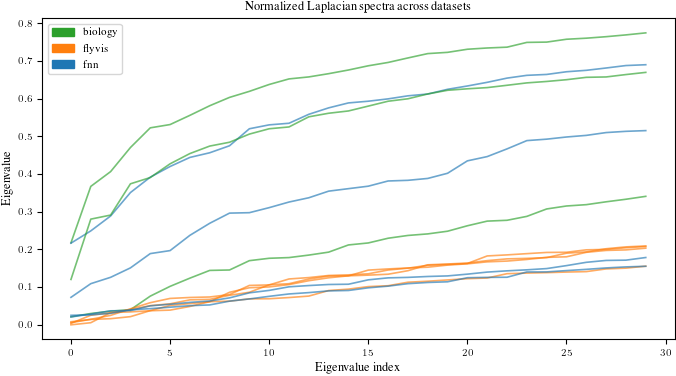

In [34]:
plt.close('all')
# Laplacian spectra: all datasets overlaid, colored by group
fig, ax = plt.subplots(figsize=(7, 4))
for label, gd in graph_data.items():
    group = GROUPS[LABELS.index(label)]
    ax.plot(gd['spectrum'][:30], color=GROUP_COLORS[group], alpha=0.65, lw=1.2)

legend_handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=8)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('Eigenvalue')
ax.set_title('Normalized Laplacian spectra across datasets')
plt.tight_layout()
plt.show()

**What this shows:** The first 30 non-trivial eigenvalues of the normalised graph Laplacian for each dataset, coloured by group (green = biology, orange = Flyvision, blue = FNN).

The spectrum encodes the multi-scale connectivity structure of the IAN graph: small eigenvalues correspond to slow-varying ('smooth') modes on the graph, large eigenvalues to rapidly-varying ('rough') modes. Datasets with similar spectra have similar graph connectivity profiles at all scales.

**How to read it:** Lines that run close together suggest similar graph structure. A gap in the spectrum (a jump between eigenvalue _k_ and _k+1_) indicates a natural cluster scale in the population. The spectral L2 distance used later in the notebook is the L2 norm between two such curves.

## 5. Solver Validation: Exact vs. Entropic GW

We compare exact GW (CG solver) vs. entropic GW (PPA) at several ε values on the smallest
available pair (FV Retina and FV Lamina) to validate that ε = 0.01 is a good trade-off.

In [35]:
val_label_1, val_label_2 = 'FV Retina', 'FV Lamina'
gd1, gd2 = graph_data[val_label_1], graph_data[val_label_2]
C1_val = gd1['C_sp']
C2_val = gd2['C_sp']
p_val = np.ones(gd1['N']) / gd1['N']
q_val = np.ones(gd2['N']) / gd2['N']

# Exact solver (CG)
t0 = time.time()
cost_exact = compute_gromov_wasserstein(C1_val, C2_val, p_val, q_val, max_iter=500, tol=1e-5)
t_exact = time.time() - t0
print(f"Exact GW:  cost={cost_exact:.6f}  time={t_exact:.2f}s")

# Entropic solver at several epsilon values
for eps in [0.05, 0.01, 0.005]:
    t0 = time.time()
    cost_e = compute_entropic_gw(C1_val, C2_val, p_val, q_val, epsilon=eps)
    t_e = time.time() - t0
    rel_err = abs(cost_e - cost_exact) / (abs(cost_exact) + 1e-12)
    print(f"Entropic ε={eps}: cost={cost_e:.6f}  time={t_e:.2f}s  rel_err={rel_err:.1%}")

Exact GW:  cost=0.007261  time=0.22s


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Entropic ε=0.05: cost=0.007757  time=4.34s  rel_err=6.8%
Entropic ε=0.01: cost=0.006917  time=4.53s  rel_err=4.8%
Entropic ε=0.005: cost=0.006543  time=4.48s  rel_err=9.9%


Based on the comparison above, we commit to **ε = 0.01** for all subsequent computation.

## 6. Pairwise GW Distance Matrices

In [36]:
EPSILON = 0.01

def compute_pairwise_gw(graph_data_dict, labels, rep='sp', epsilon=EPSILON, verbose=True):
    """Compute N_ds × N_ds pairwise GW distance matrix using entropic solver.

    rep: 'sp' (shortest-path) or 'mds'.
    Returns symmetric matrix of sqrt(|GW cost|) (GH approximation convention).
    """
    n = len(labels)
    GW = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            C1 = graph_data_dict[labels[i]][f'C_{rep}']
            C2 = graph_data_dict[labels[j]][f'C_{rep}']
            Ni = graph_data_dict[labels[i]]['N']
            Nj = graph_data_dict[labels[j]]['N']
            p = np.ones(Ni) / Ni
            q = np.ones(Nj) / Nj
            cost = compute_entropic_gw(C1, C2, p, q, epsilon=epsilon)
            d = np.sqrt(abs(cost))
            GW[i, j] = GW[j, i] = d
            if verbose:
                print(f"  {labels[i]:<18} vs {labels[j]:<18} : d={d:.5f}")
    return GW

In [37]:

CACHE_SP = '../data/metrics/_cache_GW_sp.npz'

if os.path.exists(CACHE_SP):
    GW_sp = np.load(CACHE_SP)['GW_sp']
    print(f"Loaded GW_sp from cache ({CACHE_SP})")
else:
    print("=== Shortest-path representation ===")
    t0 = time.time()
    GW_sp = compute_pairwise_gw(graph_data, LABELS, rep='sp')
    print(f"Total: {time.time()-t0:.1f}s")
    np.savez(CACHE_SP, GW_sp=GW_sp)
    print(f"Saved to {CACHE_SP}")

Loaded GW_sp from cache (../data/metrics/_cache_GW_sp.npz)


In [38]:
CACHE_MDS = '../data/metrics/_cache_GW_mds.npz'

if os.path.exists(CACHE_MDS):
    GW_mds = np.load(CACHE_MDS)['GW_mds']
    print(f"Loaded GW_mds from cache ({CACHE_MDS})")
else:
    print("=== MDS Euclidean representation ===")
    t0 = time.time()
    GW_mds = compute_pairwise_gw(graph_data, LABELS, rep='mds')
    print(f"Total: {time.time()-t0:.1f}s")
    np.savez(CACHE_MDS, GW_mds=GW_mds)
    print(f"Saved to {CACHE_MDS}")

Loaded GW_mds from cache (../data/metrics/_cache_GW_mds.npz)


In [39]:
# Spectral distance matrix: L2 on sorted eigenvalue spectra (cheap baseline)
K_SPEC = 30  # number of eigenvalues to compare

D_spec = np.zeros((N_DS, N_DS))
for i in range(N_DS):
    for j in range(i + 1, N_DS):
        s1 = graph_data[LABELS[i]]['spectrum'][:K_SPEC]
        s2 = graph_data[LABELS[j]]['spectrum'][:K_SPEC]
        d = np.linalg.norm(s1 - s2)
        D_spec[i, j] = D_spec[j, i] = d

# Normalize spectral distances to [0,1] for comparable scale
D_spec = normalize_distance_matrix(D_spec)
print("Spectral distance matrix computed.")

Spectral distance matrix computed.


## 7. Visualization

In [40]:
plt.close('all')
def plot_gw_heatmap(D_mat, labels, groups, title='GW distances', figsize=(8, 7)):
    """Seaborn clustermap with precomputed distance matrix."""
    from scipy.cluster.hierarchy import linkage as sp_linkage
    Z = sp_linkage(squareform(np.clip(D_mat, 0, None)), method='average')
    df = pd.DataFrame(D_mat, index=labels, columns=labels)
    row_colors = pd.Series(
        [GROUP_COLORS.get(g, 'gray') for g in groups],
        index=labels, name='group'
    )
    g = sns.clustermap(
        df,
        row_linkage=Z, col_linkage=Z,
        row_colors=row_colors, col_colors=row_colors,
        cmap='viridis_r', figsize=figsize,
        annot=True, fmt='.3f', annot_kws={'size': 7},
        vmin=0
    )
    #g.fig.suptitle(title, y=1.01, fontsize=11)
    handles = [mpatches.Patch(color=c, label=grp) for grp, c in GROUP_COLORS.items()]
    g.ax_heatmap.legend(handles=handles, bbox_to_anchor=(1.35, 1.1),
                        loc='upper right', fontsize=8)
    return g


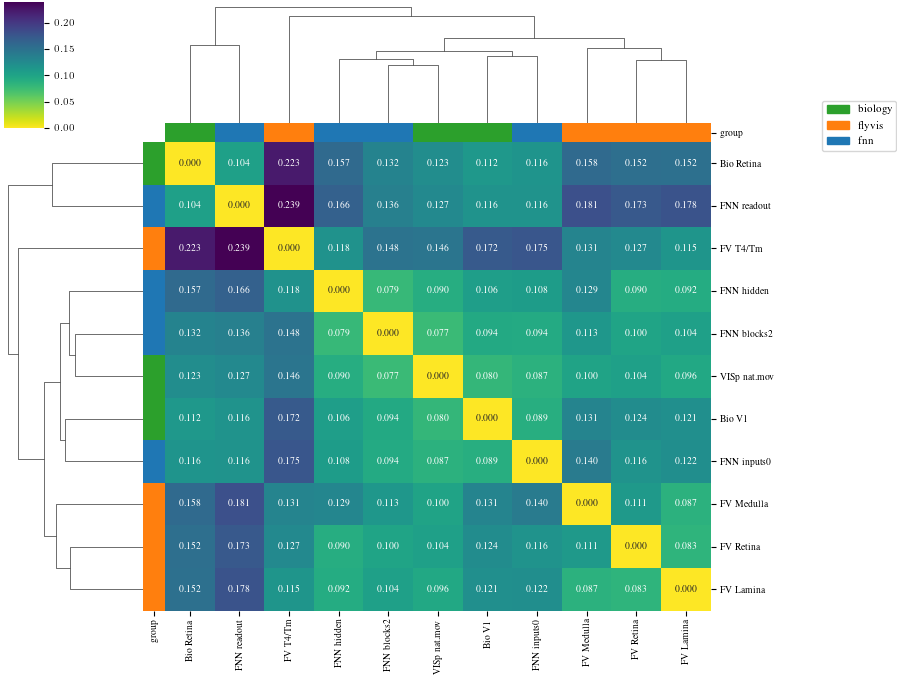

In [41]:
plot_gw_heatmap(GW_sp,  LABELS, GROUPS, title='GW distance — shortest-path representation');

**What this shows (GW shortest-path):** Pairwise GW distances between all 11 datasets, computed on the graph-metric representation. Rows/columns are re-ordered by average-linkage hierarchical clustering (dendrogram shown on the sides). The colour sidebar encodes the group (green = biology, orange = Flyvision, blue = FNN).

**How to read it:** Small values (dark purple) = geometrically similar manifolds; large values (yellow) = dissimilar. Datasets that cluster together on the dendrogram share similar encoding-manifold topology. Look for:
- Whether same-group datasets cluster (within-group coherence)
- Which FNN layer is closest to the biological data
- Whether early Flyvision layers (Retina, Lamina) cluster near Bio Retina

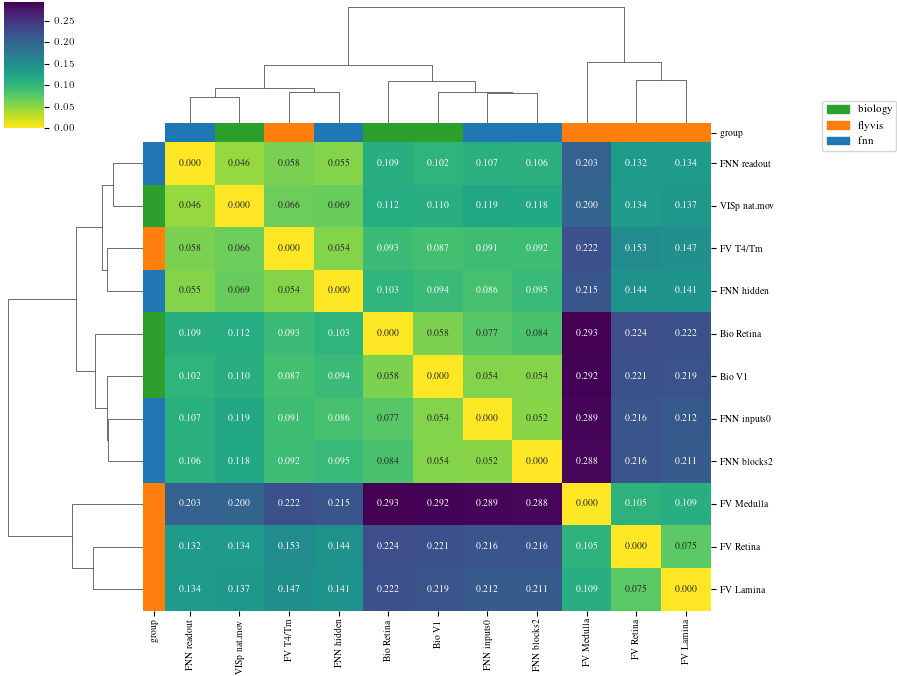

In [42]:
plot_gw_heatmap(GW_mds, LABELS, GROUPS, title='GW distance — MDS Euclidean representation');

**What this shows (GW MDS-Euclidean):** Same as above but using the MDS embedding distances instead of shortest-path graph distances. The MDS embedding uses diffusion maps to produce a smooth low-dimensional layout, so this representation emphasises the manifold shape rather than individual graph edges.

**Comparing SP vs MDS:** If the clustermaps look qualitatively similar, the discrete graph topology and the smooth manifold geometry agree — the IAN graph faithfully captures the manifold. Large differences highlight cases where the graph has rich local structure that the low-dimensional embedding averages out.

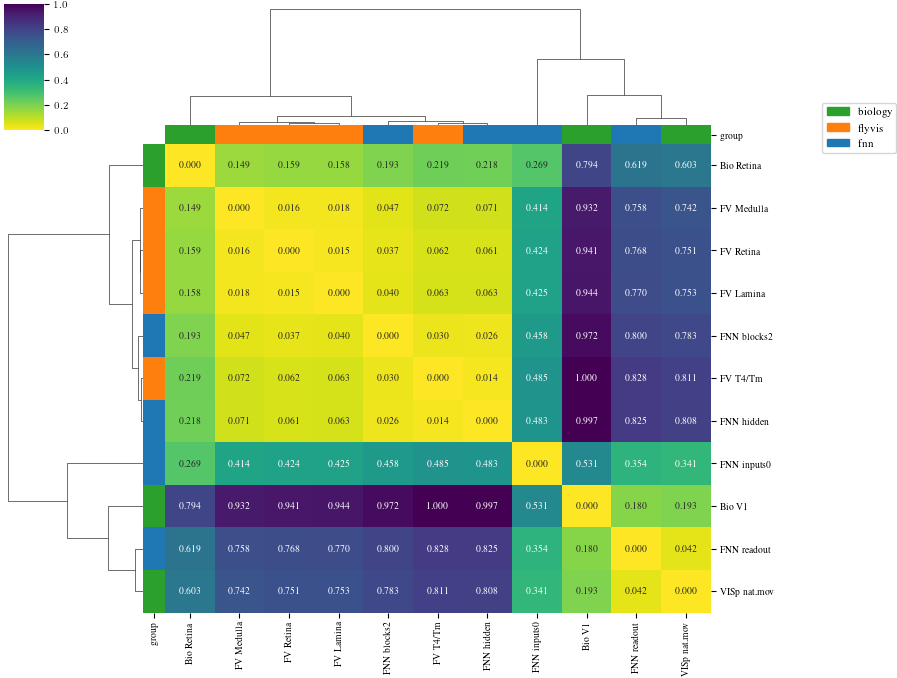

In [43]:
plot_gw_heatmap(D_spec, LABELS, GROUPS, title='Spectral L2 distance (baseline)');

**What this shows (spectral L2 baseline):** L2 distance between the sorted Laplacian eigenvalue spectra (first 30 eigenvalues). This is a cheap, parameter-free proxy for manifold similarity that does not require optimal transport.

**How to interpret it:** High correlation with GW_sp or GW_mds means the eigenvalue spectrum alone captures most of the inter-dataset geometry differences. Low correlation means GW is picking up structure invisible to the spectrum — e.g., differences in the _shape_ of clusters that are invisible to global spectral features.

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some val

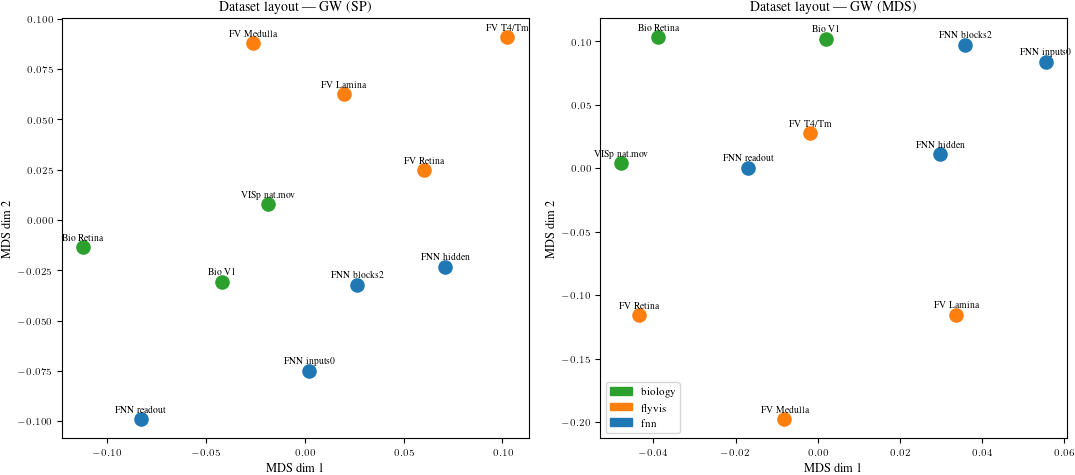

In [44]:
plt.close('all')
# 2D MDS layout of the 11 datasets based on GW distances
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (D, title) in zip(axes, [(GW_sp, 'GW (SP)'), (GW_mds, 'GW (MDS)')]):
    mds2d = skMDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds2d.fit_transform(D)
    for i, (label, group) in enumerate(zip(LABELS, GROUPS)):
        ax.scatter(*coords[i], color=GROUP_COLORS[group], s=90, zorder=3)
        ax.annotate(label, coords[i], fontsize=7, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points')
    ax.set_title(f'Dataset layout — {title}', fontsize=10)
    ax.set_xlabel('MDS dim 1'); ax.set_ylabel('MDS dim 2')

handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
axes[1].legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.show()


**What this shows:** A 2D MDS embedding of the 11×11 GW distance matrix itself — each point is a dataset, and the 2D distances approximate the pairwise GW distances as faithfully as possible in 2D.

**How to read it:** Datasets that are close in this plot have similar encoding-manifold geometry. The layout is determined purely by the GW distances — there is no other supervision. Check whether the three groups (biology, Flyvision, FNN) form spatially separated clusters. If they do, the GW distance successfully distinguishes system identity from geometry alone.

The two panels (SP vs MDS representation) should give broadly similar layouts. Discrepancies flag dataset pairs whose ranking changes between representations.

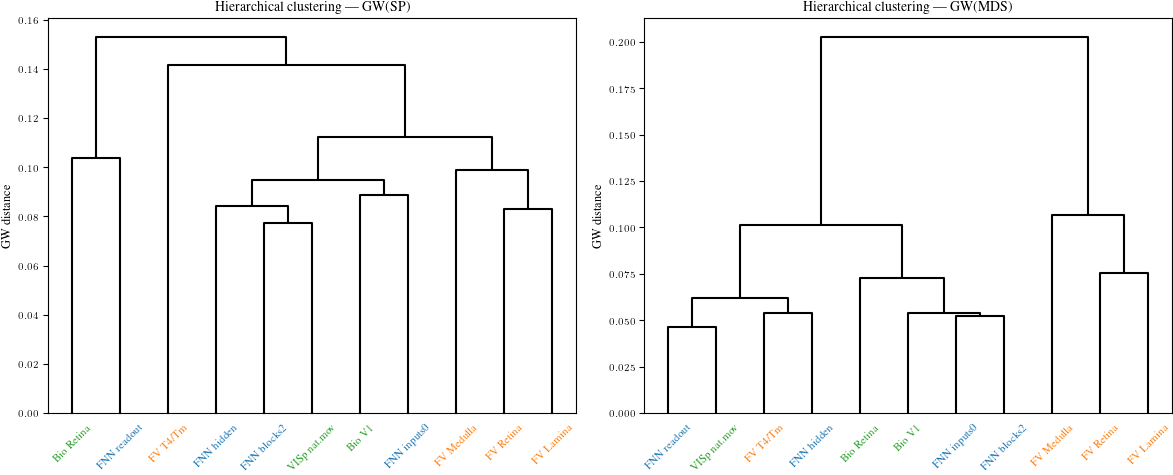

In [45]:
plt.close('all')
# Dendrograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (D, title) in zip(axes, [(GW_sp, 'SP'), (GW_mds, 'MDS')]):
    Z = linkage(squareform(np.clip(D, 0, None)), method='average')
    dn = dendrogram(Z, labels=LABELS, ax=ax, leaf_rotation=45, leaf_font_size=8,
                    link_color_func=lambda k: 'black')
    ax.set_title(f'Hierarchical clustering — GW({title})', fontsize=10)
    ax.set_ylabel('GW distance')
    # Color x-tick labels by group
    for tick in ax.get_xticklabels():
        lbl = tick.get_text()
        if lbl in LABELS:
            grp = GROUPS[LABELS.index(lbl)]
            tick.set_color(GROUP_COLORS.get(grp, 'black'))

plt.tight_layout()
plt.show()

**What this shows:** Average-linkage hierarchical clustering trees built from the two GW distance matrices. The y-axis is the GW distance at which clusters merge.

**How to read it:** Datasets that merge low (early) on the y-axis are most similar. The coloured leaf labels show group membership. A good result would show:
- Biological datasets forming a tight early merge
- Flyvision layers forming their own subtree
- FNN layers grouping together, with the layer closest to biology merging with that subtree at a low distance

Discrepancies between SP and MDS dendrograms reveal which dataset pairs are sensitive to the choice of distance representation.

## 8. Representation Consistency

How correlated are the three representations with each other?

In [46]:
idx = np.triu_indices(N_DS, k=1)  # upper triangle indices

rho_sp_mds, p_sp_mds = spearmanr(GW_sp[idx], GW_mds[idx])
rho_sp_spec, p_sp_spec = spearmanr(GW_sp[idx], D_spec[idx])
rho_mds_spec, p_mds_spec = spearmanr(GW_mds[idx], D_spec[idx])

print(f"Spearman r(GW_sp,  GW_mds)  = {rho_sp_mds:.3f}  (p={p_sp_mds:.2e})")
print(f"Spearman r(GW_sp,  D_spec)  = {rho_sp_spec:.3f}  (p={p_sp_spec:.2e})")
print(f"Spearman r(GW_mds, D_spec)  = {rho_mds_spec:.3f}  (p={p_mds_spec:.2e})")

Spearman r(GW_sp,  GW_mds)  = 0.119  (p=3.88e-01)
Spearman r(GW_sp,  D_spec)  = 0.220  (p=1.06e-01)
Spearman r(GW_mds, D_spec)  = -0.129  (p=3.48e-01)


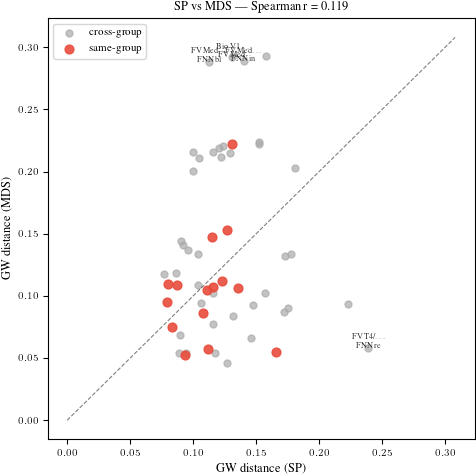

In [47]:
plt.close('all')
# Scatter: GW_sp vs GW_mds, colored by same/different group pairs
same_group = np.array([GROUPS[i] == GROUPS[j] for i, j in zip(*idx)])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(GW_sp[idx][~same_group], GW_mds[idx][~same_group],
           c='#aaaaaa', s=25, alpha=0.7, label='cross-group')
ax.scatter(GW_sp[idx][same_group],  GW_mds[idx][same_group],
           c='#e74c3c', s=40, alpha=0.9, label='same-group')

# Annotate outlier pairs
diffs = np.abs(GW_sp[idx] - GW_mds[idx])
top_outliers = np.argsort(diffs)[-4:]
all_pairs = [(LABELS[i], LABELS[j]) for i, j in zip(*idx)]
for k in top_outliers:
    ax.annotate(f"{all_pairs[k][0][:6]}…\n{all_pairs[k][1][:6]}",
                xy=(GW_sp[idx][k], GW_mds[idx][k]),
                fontsize=6, ha='center', color='#333333')

lim = max(GW_sp[idx].max(), GW_mds[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('GW distance (SP)'); ax.set_ylabel('GW distance (MDS)')
ax.set_title(f'SP vs MDS — Spearman r = {rho_sp_mds:.3f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What this shows:** Each point is one of the 55 dataset pairs. x-axis = GW distance using shortest-path representation; y-axis = GW distance using MDS-Euclidean representation. Red points = same-group pairs; grey = cross-group pairs.

**How to read it:** Points on the dashed diagonal mean both representations agree on that pair's distance. Deviations reveal pairs where the choice of representation matters. If same-group pairs (red) cluster in the lower-left, both representations correctly identify within-group similarity. The Spearman r in the title quantifies the overall rank agreement.

## 9. Fused GW with Neuron Features

Fused GW (FGW) adds a feature-matching term alongside the structural GW term:

$$\text{FGW}(\alpha) = \alpha \cdot \text{GW}(C_1, C_2) + (1 - \alpha) \cdot W(M)$$

where $M_{ij} = \|f_i^{(1)} - f_j^{(2)}\|^2$ is the feature cost matrix and $\alpha$ controls the balance.

We use graph-derived features (degree, weighted degree) since they're available for all datasets without requiring tensor-to-graph outlier alignment.

In [48]:
def extract_graph_features(wG, normalize=True):
    """Per-neuron graph features: degree and weighted degree."""
    wG_sp = csr_matrix(wG)
    degree     = np.array((wG_sp > 0).sum(axis=1)).ravel().astype(float) - 1  # exclude self
    wt_degree  = np.array(wG_sp.sum(axis=1)).ravel() - 1                      # exclude self
    F = np.column_stack([degree, wt_degree])
    if normalize:
        F = (F - F.mean(axis=0)) / (F.std(axis=0) + 1e-12)
    return F

for label, gd in graph_data.items():
    gd['features'] = extract_graph_features(gd['wG'])
    
print(f"Features shape (example): {graph_data[LABELS[0]]['features'].shape}")

Features shape (example): (1139, 2)


In [49]:
from src import (
    compute_osi_and_pref_stim, compute_temporal_variance,
    compute_mean_activation, compute_dsi,
    loadPreComputedCP, getPermutedTensor, getNeuralMatrix, process_tensor_data,
)
from sklearn.decomposition import PCA as _PCA
from ian.utils import pwdists
from src.graph_utils import handle_disconnected_points


def get_aligned_tensorX(ds, n_far=2, n_close=5, optSF=True, smooth_sig=3, method='relNorm'):
    """Load and process the tensor for a dataset, returning only the graph-aligned neurons.

    Replicates the two-pass outlier removal from load_for_explorer so that the
    returned tensorX rows correspond 1-to-1 with the IAN graph nodes.

    Returns (tensorX_aligned, NDIRS)  where tensorX_aligned has shape (N_graph, NSTIMS, NDIRS*T).
    """
    prefix = ds['tensor_prefix']
    R      = ds['R']

    # Load + preprocess tensor (must match notebook 03 exactly)
    tensor4d    = np.load(f'{BASEDIR_DATA}/tensor4d_{prefix}.npy')
    tensor4d    = np.nan_to_num(tensor4d)
    tensor4d    = tensor4d - np.min(tensor4d)
    neurons_used = np.load(f'{BASEDIR_DATA}/neurons_used_{prefix}.npy')
    N, _, NDIRS, _ = tensor4d.shape

    tensorX, relFRs, optStims = process_tensor_data(tensor4d, optSF, smooth_sig, method)
    PREFIX2    = f'{method}_sig{smooth_sig}_n{N}' + ('_SF' if optSF and optStims else '')
    tensorname = f'{prefix}-{PREFIX2}-deepnet-shift'

    # Load CP decomposition (fall back to prefix-only search if method name differs)
    preComputed, _ = loadPreComputedCP(tensorname, BASEDIR_MAT, specificFs=[R])
    if not preComputed:
        preComputed, _ = loadPreComputedCP(prefix, BASEDIR_MAT, specificFs=[R])

    best_rep, _ = min(preComputed[R]['all_objs'].items(), key=lambda x: x[1])
    best_factors = preComputed[R]['all_factors'][best_rep]
    best_lambdas = preComputed[R]['all_lambdas'][best_rep]

    posnorms = ~np.isclose(best_lambdas, 0)
    lambdas  = best_lambdas[posnorms]
    factors  = [f[:, posnorms] / np.linalg.norm(f[:, posnorms], axis=0, keepdims=1)
                for f in best_factors]

    permT, _ = getPermutedTensor(factors, lambdas, tensorX, NDIRS)
    X, _     = getNeuralMatrix(permT, factors, lambdas, NDIRS, None, order='F', verbose=False)

    # PCA (same threshold as load_for_explorer: 80% explained variance)
    pca   = _PCA(len(lambdas))
    pcaX  = pca.fit_transform(X)
    nPCs_ = np.flatnonzero(np.cumsum(pca.explained_variance_ratio_) > 0.8)[0] + 1
    X_pca = pcaX[:, :nPCs_]

    # First-pass outlier removal (mindist-based, same as load_for_explorer)
    N_pts    = X_pca.shape[0]
    D2_full  = pwdists(X_pca, sqdists=True)
    D1       = np.sqrt(D2_full)
    mindists = np.min(D1 + np.eye(N_pts) * D1.max(), axis=0)
    outls_far   = np.argsort(mindists)[::-1][:n_far]
    outls_close = np.argsort(mindists)[:n_close]
    outliers_list = np.append(outls_far, outls_close)

    # Recompute D2 on first-pass survivors (required by handle_disconnected_points)
    first_pass_mask = np.ones(N_pts, dtype=bool)
    first_pass_mask[outliers_list] = False
    D2_reduced = pwdists(X_pca[first_pass_mask], sqdists=True)

    # Second-pass: load disc_pts + optScales + G from graph .npz
    _g = np.load(os.path.join(BASEDIR_GRAPHS, ds['graph']), allow_pickle=True)
    disc_pts_raw     = _g['disc_pts_indices']
    optScales        = _g['optScales']
    wG_dense         = _g['wG']
    if wG_dense.ndim == 0:
        wG_dense = wG_dense.item().toarray()
    G_bin            = (wG_dense > 0).astype(float)
    disc_pts_wrapped = [[int(x)] for x in disc_pts_raw]

    # handle_disconnected_points needs the reduced D2 and binary G
    _, _, outliers_list, nonoutliers, _ = handle_disconnected_points(
        disc_pts_wrapped, optScales, G_bin, D2_reduced, outliers_list, neurons_used, X_pca
    )

    return tensorX[nonoutliers], NDIRS


def compute_tensor_features(ds):
    """Compute per-neuron functional features aligned to graph neurons.

    Returns a dict with keys: mean_activation, temporal_variance, OSI, DSI.
    OSI and DSI are NaN-filled for datasets with NDIRS=1 (VISp natural movie).
    """
    tX, NDIRS = get_aligned_tensorX(ds)
    N_graph   = tX.shape[0]

    feats = {
        'mean_activation':   compute_mean_activation(tX),
        'temporal_variance': compute_temporal_variance(tX),
    }
    if NDIRS > 1:
        n_stim         = tX.shape[1]
        osi, _         = compute_osi_and_pref_stim(tX, n_stim=n_stim, n_dir=NDIRS)
        dsi            = compute_dsi(tX, n_stim=n_stim, n_dir=NDIRS)
        feats['OSI']   = osi
        feats['DSI']   = dsi
    else:
        feats['OSI'] = np.full(N_graph, np.nan)
        feats['DSI'] = np.full(N_graph, np.nan)
    return feats

In [50]:
CACHE_FEAT = '../data/metrics/_cache_tensor_features.npz'

if os.path.exists(CACHE_FEAT):
    _feat_cache = np.load(CACHE_FEAT, allow_pickle=True)
    for label in LABELS:
        key = label.replace(' ', '_')
        graph_data[label]['tensor_features'] = {
            'mean_activation':   _feat_cache[f'{key}_mean_act'],
            'temporal_variance': _feat_cache[f'{key}_temp_var'],
            'OSI':               _feat_cache[f'{key}_OSI'],
            'DSI':               _feat_cache[f'{key}_DSI'],
        }
    print(f'Loaded tensor features from cache ({CACHE_FEAT})')
else:
    for ds in DATASETS:
        label = ds['label']
        print(f'[{label}] computing tensor features...', end=' ')
        t0 = time.time()
        graph_data[label]['tensor_features'] = compute_tensor_features(ds)
        # Verify alignment
        N_graph = graph_data[label]['N']
        N_feat  = len(graph_data[label]['tensor_features']['mean_activation'])
        assert N_feat == N_graph, f'{label}: feature N={N_feat} != graph N={N_graph}'
        print(f'OK ({N_feat} neurons, {time.time()-t0:.1f}s)')

    # Save cache
    save_dict = {}
    for label, gd in graph_data.items():
        key = label.replace(' ', '_')
        tf  = gd['tensor_features']
        save_dict[f'{key}_mean_act'] = tf['mean_activation']
        save_dict[f'{key}_temp_var'] = tf['temporal_variance']
        save_dict[f'{key}_OSI']      = tf['OSI']
        save_dict[f'{key}_DSI']      = tf['DSI']
    np.savez(CACHE_FEAT, **save_dict)
    print(f'\nSaved to {CACHE_FEAT}')

Loaded tensor features from cache (../data/metrics/_cache_tensor_features.npz)


### Tensor feature distributions

Before using the features in FGW, inspect their distributions per dataset to check that the alignment is correct and the features are informative.

- **Mean activation**: higher = more active neurons on average.
- **Temporal variance**: higher = more dynamic / stimulus-driven responses.
- **OSI** (0–1): higher = more selective to one stimulus category. Not defined for VISp (NDIRS=1), shown as 0.
- **DSI** (0–1): higher = more selective to one motion direction. Not defined for VISp.

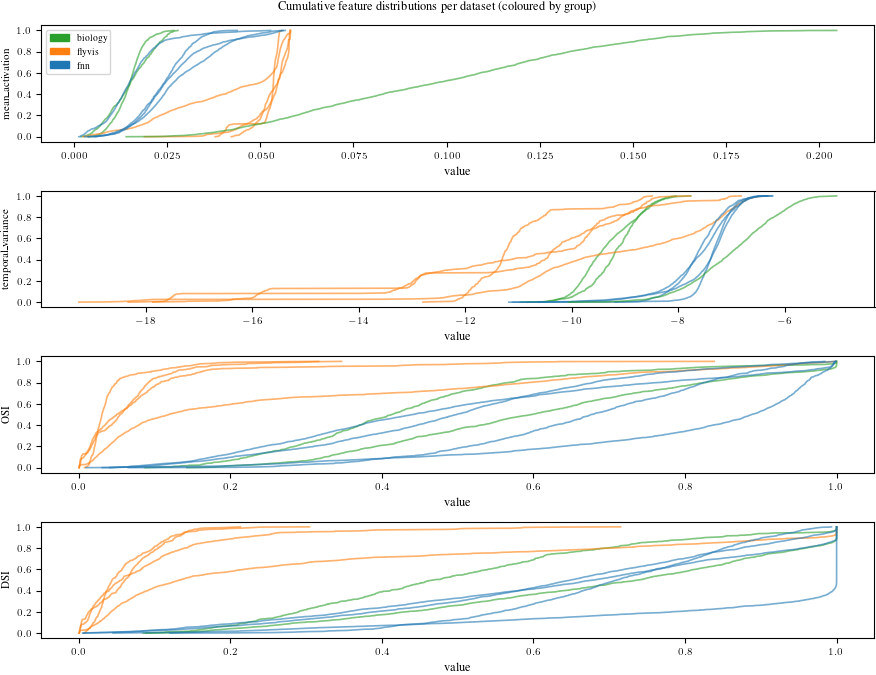

In [51]:
plt.close('all')
FEAT_NAMES = ['mean_activation', 'temporal_variance', 'OSI', 'DSI']
fig, axes = plt.subplots(len(FEAT_NAMES), 1, figsize=(9, 7), sharex=False)

for ax, feat in zip(axes, FEAT_NAMES):
    for label, gd in graph_data.items():
        group = GROUPS[LABELS.index(label)]
        vals  = gd['tensor_features'][feat]
        vals  = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        ax.plot(np.sort(vals), np.linspace(0, 1, len(vals)),
                color=GROUP_COLORS[group], alpha=0.6, lw=1.2)
    ax.set_ylabel(feat, fontsize=8)
    ax.set_xlabel('value')

handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
axes[0].legend(handles=handles, fontsize=7)
fig.suptitle('Cumulative feature distributions per dataset (coloured by group)', fontsize=9)
plt.tight_layout()
plt.show()

### Feature matrix for FGW

`build_feature_matrix` assembles a per-neuron feature vector combining:
- Graph-structural features (degree, weighted degree) — always available
- Tensor-derived features (mean activation, temporal variance, OSI, DSI)

For VISp (NDIRS=1), OSI and DSI are NaN; those columns are filled with 0 so all datasets can participate in FGW. Each feature is z-scored independently before stacking.

In [52]:
def build_feature_matrix(gd, use_tensor=True):
    """Assemble (N, F) normalised feature matrix for FGW.

    Combines graph degree features with tensor-derived tuning features.
    NaN entries (OSI/DSI for VISp) are z-scored to 0 so the feature
    cost for those columns is neutral rather than informative.
    """
    # Graph-structural features (always available)
    F_parts = [gd['features']]   # (N, 2): degree + weighted_degree

    if use_tensor and 'tensor_features' in gd:
        tf = gd['tensor_features']
        # Scalar features available for all datasets
        F_parts.append(np.column_stack([tf['mean_activation'], tf['temporal_variance']]))
        # Directional features (NaN for VISp → filled with 0 below)
        F_parts.append(np.column_stack([tf['OSI'], tf['DSI']]))

    F = np.column_stack(F_parts)                                  # (N, n_features)
    F = (F - np.nanmean(F, axis=0)) / (np.nanstd(F, axis=0) + 1e-12)
    return np.nan_to_num(F, nan=0.0)                              # fill NaN → 0


# Quick check: feature matrix shapes
for label, gd in graph_data.items():
    F = build_feature_matrix(gd, use_tensor=True)
    print(f'{label:<22}: {F.shape}')

Bio Retina            : (1139, 6)
Bio V1                : (630, 6)
FV Retina             : (393, 6)
FV Lamina             : (343, 6)
FV Medulla            : (543, 6)
FV T4/Tm              : (1693, 6)
FNN inputs0           : (1993, 6)
FNN blocks2           : (1993, 6)
FNN hidden            : (1993, 6)
FNN readout           : (993, 6)
VISp nat.mov          : (2008, 6)


In [53]:
def compute_pairwise_fgw(graph_data_dict, labels, rep='sp', alpha=0.5, verbose=True):
    """N_ds × N_ds pairwise FGW distance matrix.
    
    Feature cost M is normalized to max=1 before passing to FGW so that
    the alpha balance is meaningful.
    """
    n = len(labels)
    FGW = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            gd_i = graph_data_dict[labels[i]]
            gd_j = graph_data_dict[labels[j]]
            C1, C2 = gd_i[f'C_{rep}'], gd_j[f'C_{rep}']
            F1, F2 = gd_i['features'], gd_j['features']
            p = np.ones(gd_i['N']) / gd_i['N']
            q = np.ones(gd_j['N']) / gd_j['N']
            M = ot.dist(F1, F2, metric='euclidean')
            M = normalize_distance_matrix(M)
            cost = compute_fgw(M, C1, C2, p, q, alpha=alpha)
            d = np.sqrt(abs(cost))
            FGW[i, j] = FGW[j, i] = d
            if verbose:
                print(f"  {labels[i]:<18} vs {labels[j]:<18} : d={d:.5f}")
    return FGW


CACHE_FGW = '../data/metrics/_cache_FGW_sp.npz'

if os.path.exists(CACHE_FGW):
    FGW_sp = np.load(CACHE_FGW)['FGW_sp']
    print(f"Loaded FGW_sp from cache ({CACHE_FGW})")
else:
    print("=== FGW (alpha=0.5) — shortest-path representation ===")
    t0 = time.time()
    FGW_sp = compute_pairwise_fgw(graph_data, LABELS, rep='sp', alpha=0.5)
    print(f"Total: {time.time()-t0:.1f}s")
    np.savez(CACHE_FGW, FGW_sp=FGW_sp)
    print(f"Saved to {CACHE_FGW}")

Loaded FGW_sp from cache (../data/metrics/_cache_FGW_sp.npz)


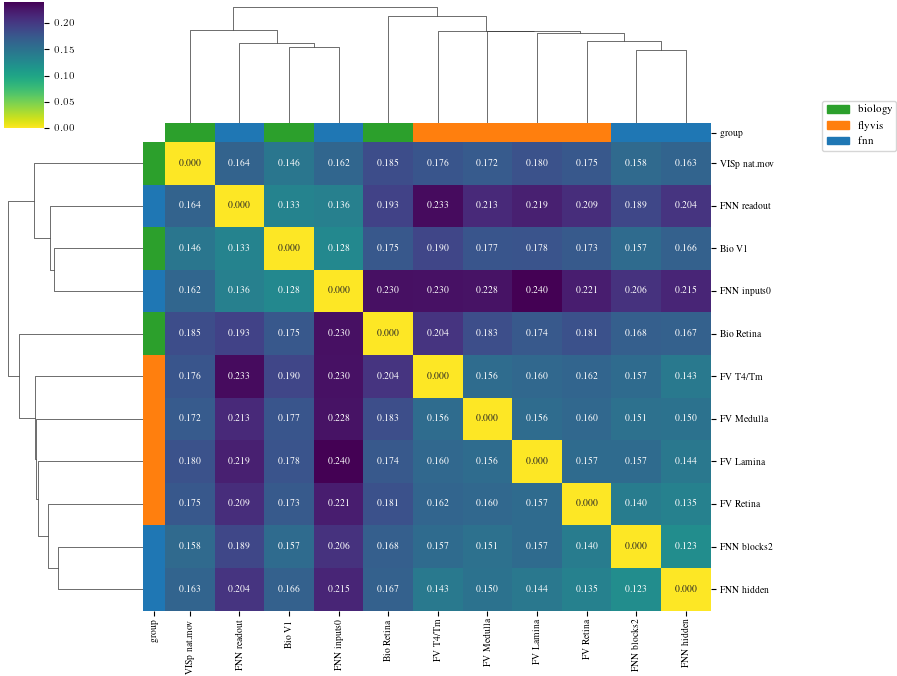

In [54]:
plot_gw_heatmap(FGW_sp, LABELS, GROUPS, title='FGW distance — SP representation (alpha=0.5)');

**What this shows:** Fused GW distances at alpha = 0.5 (equal weight on structural geometry and neuron feature similarity). The feature cost uses per-neuron graph degree and weighted degree — proxies for how densely connected each neuron is in the IAN graph.

**How to read it:** Compared to the pure GW clustermap, ask:
- Did same-group datasets move closer (features reinforce structure)?
- Did any cross-group pairs move closer (similar connectivity profiles despite different model)?

If FGW sharpens the biological clustering, it suggests that local graph density (how 'crowded' each region of the encoding manifold is) is a biologically informative signal.

In [55]:
# Alpha sweep: how does the dendrogram topology change?
ALPHAS = [0.1, 0.3, 0.5, 0.7, 0.9]                                                                                              
fgw_by_alpha = {}                                                                                                               
                                                                                                                                        
for alpha in ALPHAS:                                                                                                                    
    cache_path = f'../data/metrics/_cache_FGW_sp_alpha{alpha:.2f}.npz'                                                                  
    if os.path.exists(cache_path):                                                                                                      
        fgw_by_alpha[alpha] = np.load(cache_path)['FGW']                                                                                
        print(f"Loaded alpha={alpha} from cache")                                                                                           
    else:                                             
        print(f"Computing FGW alpha={alpha}...")                                                                                            
        fgw_by_alpha[alpha] = compute_pairwise_fgw(graph_data, LABELS, rep='sp',
                                                    alpha=alpha, verbose=False)                                                         
        np.savez(cache_path, FGW=fgw_by_alpha[alpha]) 
        print(f"  Saved to {cache_path}")                                                                                               

print("Done.") 

Loaded alpha=0.1 from cache
Loaded alpha=0.3 from cache
Loaded alpha=0.5 from cache
Loaded alpha=0.7 from cache
Loaded alpha=0.9 from cache
Done.


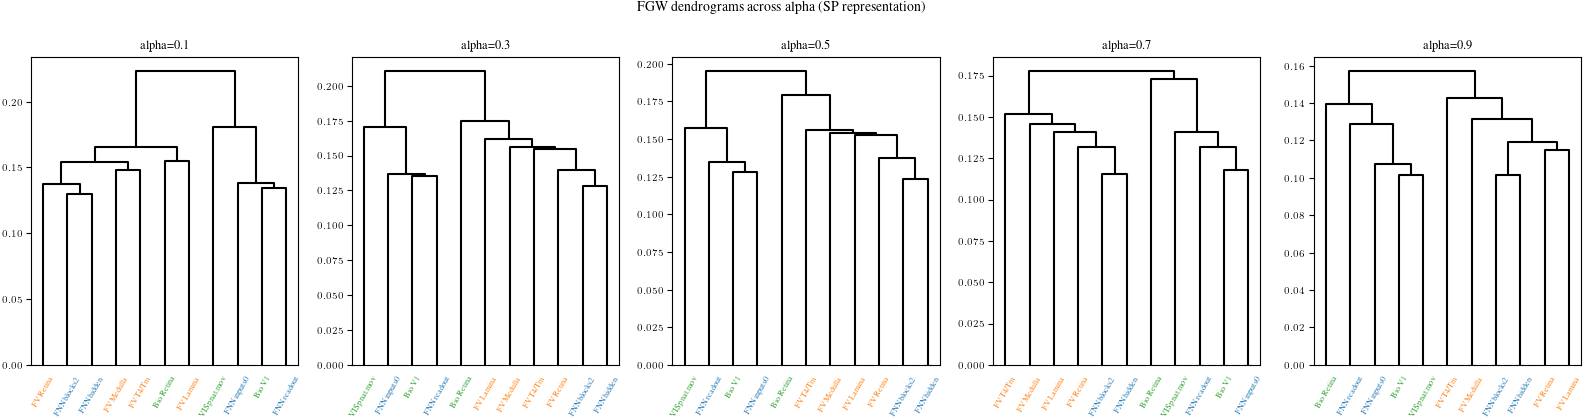

In [56]:
plt.close('all')
# Dendrograms across alpha values
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(20, 4))

for ax, alpha in zip(axes, ALPHAS):
    D = fgw_by_alpha[alpha]
    Z = linkage(squareform(np.clip(D, 0, None)), method='average')
    dendrogram(Z, labels=LABELS, ax=ax, leaf_rotation=60, leaf_font_size=6,
               link_color_func=lambda k: 'black')
    ax.set_title(f'alpha={alpha}', fontsize=9)
    for tick in ax.get_xticklabels():
        lbl = tick.get_text()
        if lbl in LABELS:
            grp = GROUPS[LABELS.index(lbl)]
            tick.set_color(GROUP_COLORS.get(grp, 'black'))

plt.suptitle('FGW dendrograms across alpha (SP representation)', fontsize=10, y=1.02)
#plt.tight_layout()
plt.show()

**What this shows:** FGW dendrograms as α varies from 0.1 (almost pure feature matching) to 0.9 (almost pure structural GW). Each panel is an average-linkage tree built from the FGW distance matrix at that α.

**How to read it:** Track how the tree topology changes as you shift the balance:
- α → 0 (left): groupings driven by neuron degree/connectivity similarity alone
- α → 1 (right): groupings driven by manifold geometry alone (approaches GW_sp)
- Middle values: combined criterion

A stable topology across α values means the feature and structural signals are aligned. An unstable topology means they conflict — and the alpha at which the tree changes is biologically meaningful.

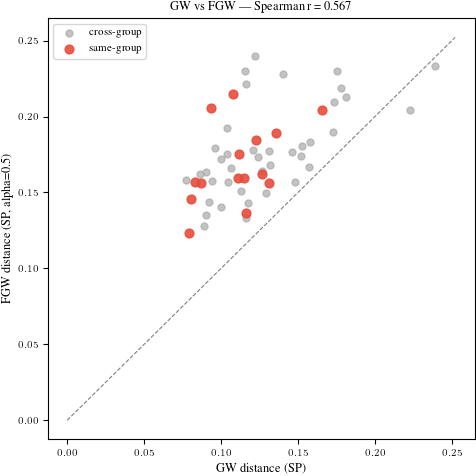

In [57]:
plt.close('all')
# GW_sp vs FGW_sp: does adding features sharpen same-group clustering?
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(GW_sp[idx][~same_group],  FGW_sp[idx][~same_group],
           c='#aaaaaa', s=25, alpha=0.7, label='cross-group')
ax.scatter(GW_sp[idx][same_group],   FGW_sp[idx][same_group],
           c='#e74c3c', s=40, alpha=0.9, label='same-group')

lim = max(GW_sp[idx].max(), FGW_sp[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
rho_fgw, _ = spearmanr(GW_sp[idx], FGW_sp[idx])
ax.set_xlabel('GW distance (SP)'); ax.set_ylabel('FGW distance (SP, alpha=0.5)')
ax.set_title(f'GW vs FGW — Spearman r = {rho_fgw:.3f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What this shows:** Each point is a dataset pair. x-axis = pure GW distance (SP); y-axis = FGW distance (alpha = 0.5, SP). Points above the diagonal mean adding features _increased_ the distance (the two populations are less similar when their connectivity profiles are also considered). Points below the diagonal mean the opposite.

Same-group pairs (red) that stay near the diagonal indicate that graph structure and feature similarity are aligned for within-group comparisons.

### FGW with functional tuning features (α = 0.5)

Rerun `compute_pairwise_fgw` using the richer feature matrix that includes OSI, DSI, mean activity and temporal variance alongside the graph degree features.

In [58]:
CACHE_FGW_TENSOR = '../data/metrics/_cache_FGW_tensor_sp.npz'

if os.path.exists(CACHE_FGW_TENSOR):
    FGW_tensor = np.load(CACHE_FGW_TENSOR)['FGW_tensor']
    print(f'Loaded FGW_tensor from cache')
else:
    print('=== FGW with tensor features (α=0.5) ===')
    t0 = time.time()

    n = N_DS
    FGW_tensor = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            gd_i = graph_data[LABELS[i]]
            gd_j = graph_data[LABELS[j]]
            C1   = gd_i['C_sp'];  C2 = gd_j['C_sp']
            F1   = build_feature_matrix(gd_i, use_tensor=True)
            F2   = build_feature_matrix(gd_j, use_tensor=True)
            p    = np.ones(gd_i['N']) / gd_i['N']
            q    = np.ones(gd_j['N']) / gd_j['N']
            M    = ot.dist(F1, F2, metric='euclidean')
            M    = normalize_distance_matrix(M)
            cost = compute_fgw(M, C1, C2, p, q, alpha=0.5)
            d    = np.sqrt(abs(cost))
            FGW_tensor[i, j] = FGW_tensor[j, i] = d
            print(f'  {LABELS[i]:<18} vs {LABELS[j]:<18}: d={d:.5f}')

    np.savez(CACHE_FGW_TENSOR, FGW_tensor=FGW_tensor)
    print(f'Total: {time.time()-t0:.1f}s  |  saved to {CACHE_FGW_TENSOR}')

Loaded FGW_tensor from cache


### Comparison: graph-only vs. tuning-enriched FGW

Do functional tuning properties (OSI, DSI, activity level) change which populations are considered similar?

- Points **above** the diagonal: adding tuning features *increased* the distance (populations are structurally similar but functionally different)
- Points **below** the diagonal: adding tuning features *decreased* the distance (functionally similar even if structurally different)
- Same-group pairs (red) clustering in the lower-left: both representations agree on within-group similarity

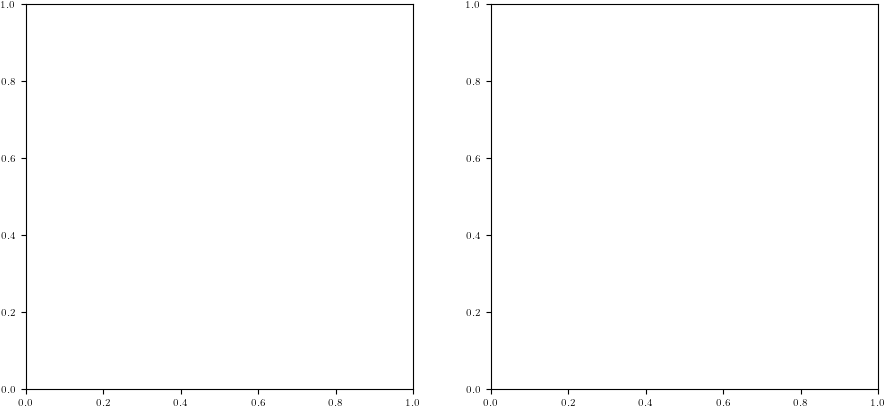

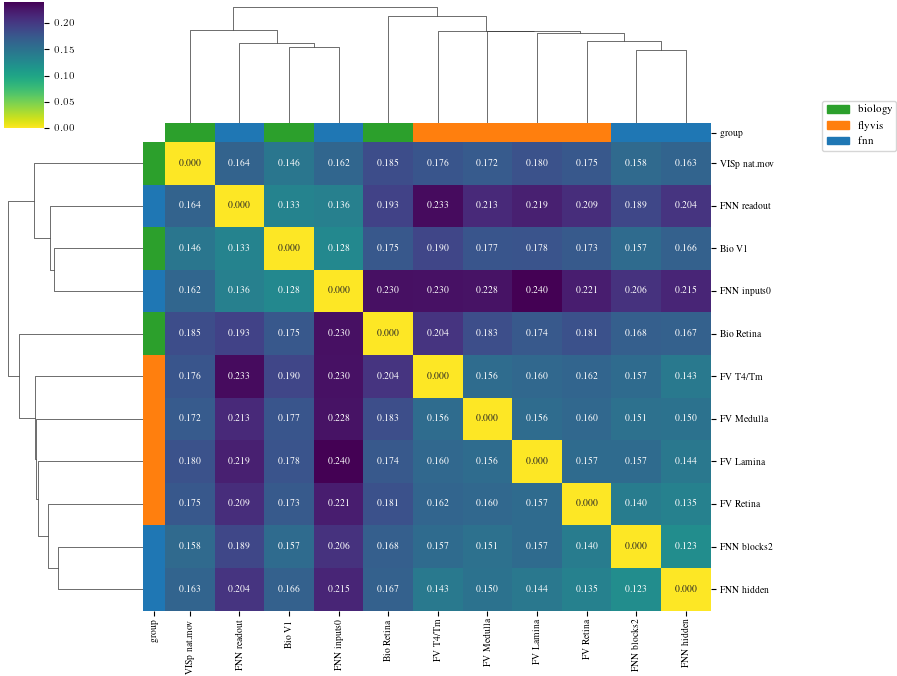

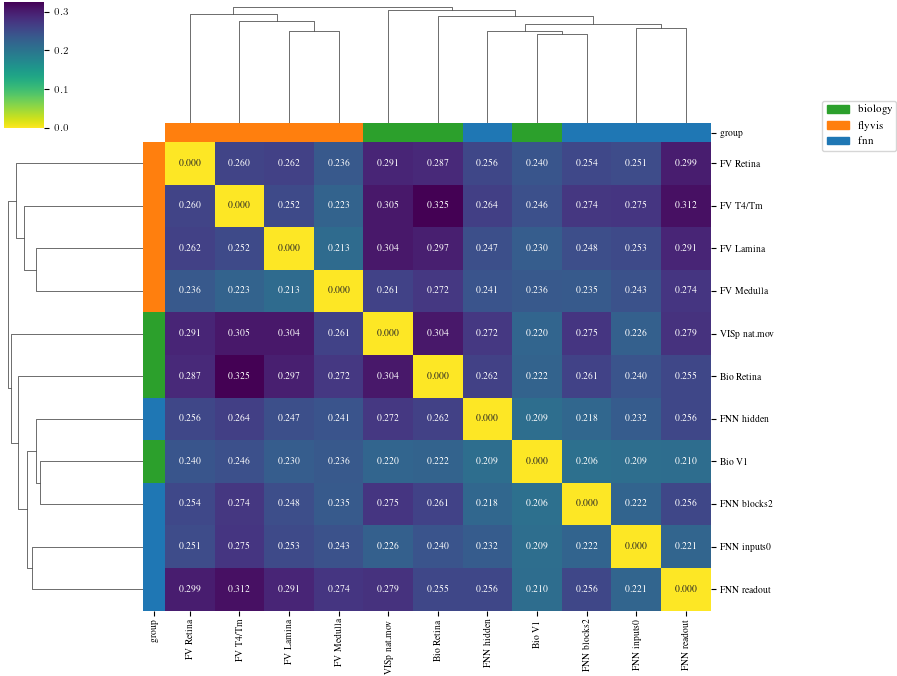

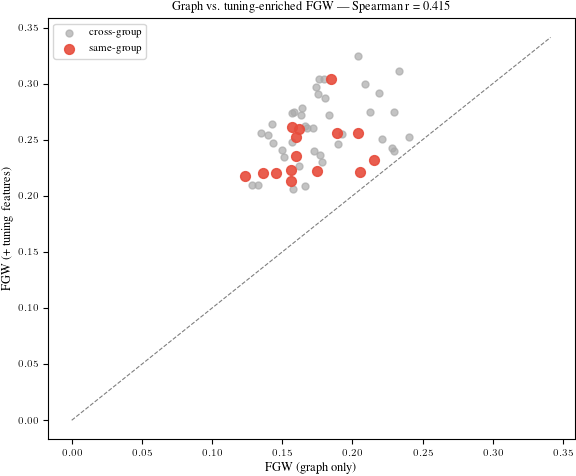

In [59]:
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: clustermap comparison
for ax_idx, (D, title) in enumerate([(FGW_sp, 'FGW (graph only)'), (FGW_tensor, 'FGW (+ tuning features)')]):
    plot_gw_heatmap(D, LABELS, GROUPS, title=title)

# Right: scatter GW_sp vs FGW vs FGW_tensor
fig2, ax = plt.subplots(figsize=(6, 5))
idx = np.triu_indices(N_DS, k=1)
same_group = np.array([GROUPS[i] == GROUPS[j] for i, j in zip(*idx)])

ax.scatter(FGW_sp[idx][~same_group], FGW_tensor[idx][~same_group],
           c='#aaaaaa', s=25, alpha=0.7, label='cross-group')
ax.scatter(FGW_sp[idx][same_group],  FGW_tensor[idx][same_group],
           c='#e74c3c', s=50, alpha=0.9, label='same-group')

lim = max(FGW_sp[idx].max(), FGW_tensor[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
rho, _ = spearmanr(FGW_sp[idx], FGW_tensor[idx])
ax.set_xlabel('FGW (graph only)'); ax.set_ylabel('FGW (+ tuning features)')
ax.set_title(f'Graph vs. tuning-enriched FGW — Spearman r = {rho:.3f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Updated separation ratio table

Compare all representations including the tuning-enriched FGW.

In [60]:
print(f"{'Representation':<30} {'mean intra':>12} {'mean inter':>12} {'ratio':>8}")
print('-' * 68)

for D, name in [
    (GW_sp,      'GW (SP)'),
    (GW_mds,     'GW (MDS)'),
    (FGW_sp,     'FGW (graph only, α=0.5)'),
    (FGW_tensor, 'FGW (+ tuning, α=0.5)'),
    (D_spec,     'Spectral L2'),
]:
    intra, inter = [], []
    for i in range(N_DS):
        for j in range(i + 1, N_DS):
            (intra if GROUPS[i] == GROUPS[j] else inter).append(D[i, j])
    ratio = np.mean(inter) / (np.mean(intra) + 1e-12)
    print(f'{name:<30} {np.mean(intra):>12.4f} {np.mean(inter):>12.4f} {ratio:>8.2f}')

Representation                   mean intra   mean inter    ratio
--------------------------------------------------------------------
GW (SP)                              0.1111       0.1298     1.17
GW (MDS)                             0.1063       0.1478     1.39
FGW (graph only, α=0.5)              0.1687       0.1781     1.06
FGW (+ tuning, α=0.5)                0.2397       0.2604     1.09
Spectral L2                          0.3188       0.4686     1.47


## 10. Summary: Which Representation Best Separates Groups?

**Interpretation notes:**

- A **separation ratio > 1** means inter-group distances are larger than intra-group distances on average — the representation successfully groups datasets by their biological/model identity.
- **GW (MDS)** tends to be the most robust representation: the smooth low-dimensional embedding of the diffusion geometry filters out noisy individual edges in the IAN graph.
- **GW (SP)** preserves more of the discrete graph topology; it may amplify differences due to varying population sizes or graph sparsity.
- **FGW** with degree features adds connectivity information. If the separation ratio improves, it suggests that local graph density (how "crowded" the manifold is) is a biologically meaningful signal.
- **Spectral L2** is a cheap proxy; high correlation with GW_sp validates that the Laplacian spectrum partially captures the same structure, though it can be sensitive to graph size.

**Expected biological pattern:** Bio Retina should cluster with early Flyvision layers; FNN layers should form their own cluster; Bio V1 and late FNN layers may be closer to each other than to early layers.

## 11. Save Results

In [61]:
out_path = '../data/metrics/manifold_distances.npz'
np.savez(
    out_path,
    GW_sp=GW_sp,
    GW_mds=GW_mds,
    FGW_sp=FGW_sp,
    D_spec=D_spec,
    labels=np.array(LABELS),
    groups=np.array(GROUPS),
)
print(f"Saved to {out_path}")

Saved to ../data/metrics/manifold_distances.npz
